---
# Regresiones Lineales Univariadas


---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#### Carga de los datos a analizar

In [2]:
df = pd.read_csv('Galton.txt', sep='\t')

#### Breve análisis exploratorio

In [3]:
df.head()

,Family,Father,Mother,Gender,Height,Kids
0,1,78.5,67.0,M,73.2,4
1,1,78.5,67.0,F,69.2,4
2,1,78.5,67.0,F,69.0,4
3,1,78.5,67.0,F,69.0,4
4,2,75.5,66.5,M,73.5,4


In [4]:
df.groupby('Gender').mean()

,Father,Mother,Height,Kids
Gender,,,,
F,69.302309,64.169515,64.110162,6.311778
M,69.168172,64.005161,69.228817,5.972043


#### Análisis visual

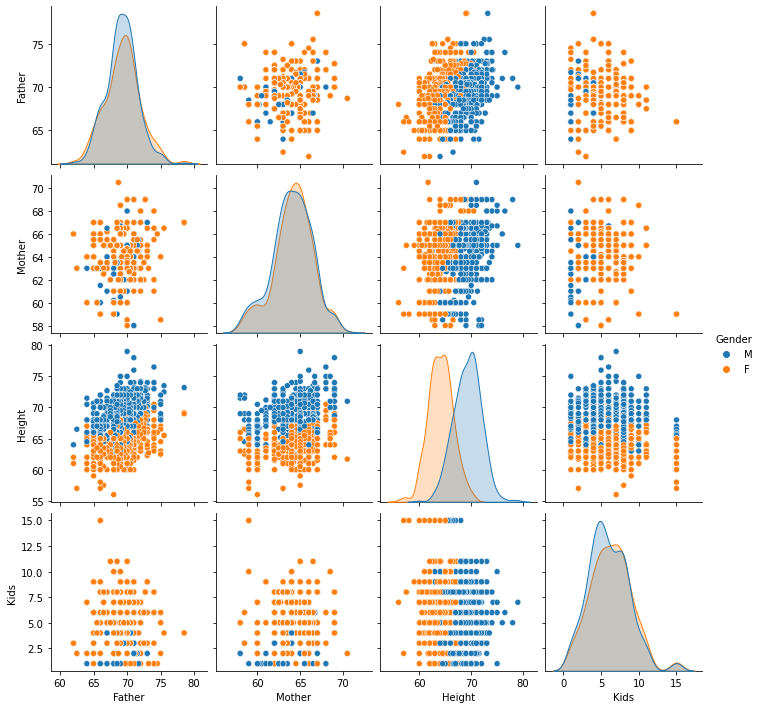

In [5]:
sns.pairplot(data=df, hue='Gender')

### Hipótesis de Trabajo

El modelo lo vamos a plantear en función del tamaño de la hija con el de la madre, por lo tanto creamos un dataframe con los datos del género femenino

In [6]:
df_f = df[ df['Gender']=='F' ]
df_f

,Family,Father,Mother,Gender,Height,Kids
1,1,78.5,67.0,F,69.2,4
2,1,78.5,67.0,F,69.0,4
3,1,78.5,67.0,F,69.0,4
6,2,75.5,66.5,F,65.5,4
7,2,75.5,66.5,F,65.5,4
...,...,...,...,...,...,...
887,203,62.0,66.0,F,61.0,3
889,204,62.5,63.0,F,57.0,2
895,136A,68.5,65.0,F,64.0,8
896,136A,68.5,65.0,F,63.5,8


Graficamos la dispersión de ambas variables

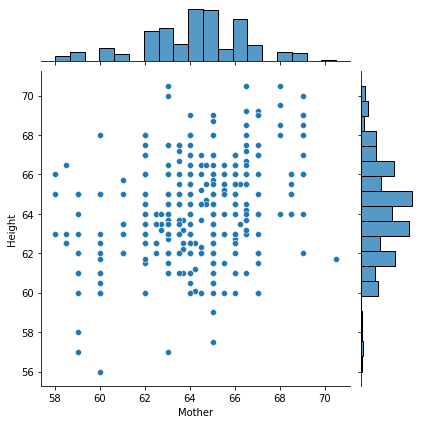

In [7]:
sns.jointplot(data=df_f, x='Mother', y='Height')

### Formulación del Modelo

In [8]:
X=df_f[['Mother']]
y=df_f[['Height']]

In [9]:
X.head()

,Mother
1,67.0
2,67.0
3,67.0
6,66.5
7,66.5


### Validación Cruzada

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)

(346, 1)
(87, 1)


### Entrenamiento del modelo lineal

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

In [15]:
# coeficientes ajustados
lm.coef_

array([[0.32561679]])

In [16]:
# intercepto 
lm.intercept_

array([43.17026675])

In [ ]:
y=43.17+0.32x

#### Haciendo algunas predicciones

In [17]:
# predicciones sobre un valor
p1 = [[62]]
lm.predict(p1)

array([[63.35850788]])

In [18]:
# predicciones sobre varios valores
p2 = [[50],
      [55],
      [60],
      [65],
      [70]]
lm.predict(p2)

array([[59.45110637],
       [61.07919033],
       [62.70727429],
       [64.33535826],
       [65.96344222]])

In [19]:
# predicciones sobre el set de test
y_pred = lm.predict(X_test)

In [23]:
X_test[:5]

,Mother
881,64.0
137,66.0
357,63.0
54,65.0
765,66.0


In [20]:
y_pred[:5]

array([[64.00974146],
       [64.66097505],
       [63.68412467],
       [64.33535826],
       [64.66097505]])

In [21]:
y_test[:5]

,Height
881,60.0
137,66.5
357,64.0
54,64.5
765,65.5


In [22]:
# el promedio de altura de las hijas mujeres
df_f['Height'].mean()

64.11016166281759

#### Graficando la recta de regresión

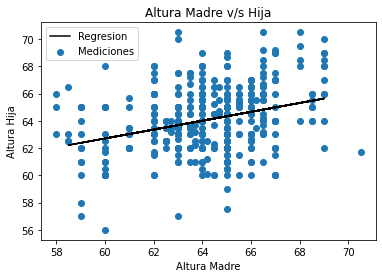

In [24]:
plt.scatter(df_f[['Mother']],df_f['Height'], label='Mediciones')
plt.plot(X_test,y_pred, color='black', label='Regresion')
plt.xlabel('Altura Madre')
plt.ylabel('Altura Hija')
plt.title('Altura Madre v/s Hija')
plt.legend(loc=0)

#### Métricas de Error

In [26]:
from sklearn import metrics

Calculando las métricas de error

In [27]:
# Mean Absolute Error
metrics.mean_absolute_error(y_test,y_pred)

1.9628377999047737

In [28]:
# Mean Squared Error
metrics.mean_squared_error(y_test,y_pred)

6.423322381500187

In [29]:
# Root Medium Squared Error
metrics.mean_squared_error(y_test,y_pred)**.5

2.53442742675741

Indicador R-cuadrado

In [31]:
# R-Squared
lm.score(X_train,y_train)

0.10638694441623375

#### Análisis de Residuales

/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

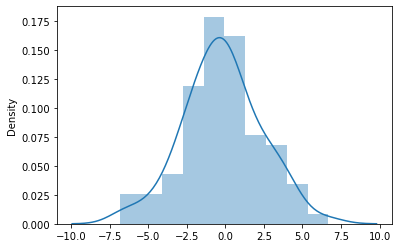

In [33]:
sns.distplot(y_pred-y_test)

Graficamos el valor real versus el valor predicho

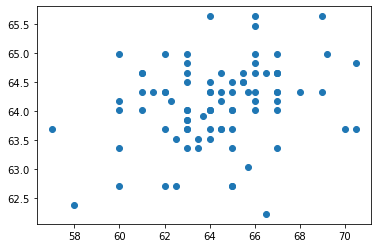

In [34]:
plt.scatter(y_test,y_pred)